<a href="https://colab.research.google.com/github/AbdullahSoboh/SYSC4415/blob/main/A2_SYSC4415_W26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SYSC4415 W26 Assignment 2 – Fire Hydrant Detection 🚒

Special thanks to Nader Ibrahim for assembling the dataset. For more details, please refer to the paper:

Ibrahim N, Dick K, Green JR. Computer Vision Fire Hydrant Obstruction Detection System. In2024 IEEE Canadian Conference on Electrical and Computer Engineering (CCECE) 2024 Aug 6 (pp. 799-805). IEEE.


Questions? Please use the Brightspace Discussion Board.

Deadline: See Brightspace end date.

## Instructions
DO NOT wait until the last minute to complete this assignment as training the models might take longer. Also leverage the free GPU provided by colab to make your training faster.


Follow all steps carefully. Your solutions must be self-contained in this notebook. No other supplementary materials or files will be accepted. As soon as I open your notebook, I will click "Runtime" → "Run all". Ensure your notebook runs without errors and displays results clearly.


You are asked to provide both code and text to address discussion questions. For the text answers, see the markdown cells with the ❓ emoji for questions and enter your answers following the ✅ emoji.

Provide sufficient comments in your code to describe its functionality. Do not remove any necessary libraries as this will cause errors.

Download the dataset from Brightspace and store it in your Google Drive under "My Drive" (not in any subfolder). Check the file location via right-click → File Information → Details → Location.

Submit your notebook as a `.ipynb` file named: `SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb` on Brightspace. No other submission methods will be accepted.


## Dataset
Provided on Brightspace.

#### Dataset details:
- Training Images: 2,272  
- Validation Images: 563  
- Labels: 0 = No Fire Hydrant, 1 = Fire Hydrant  
- Imbalanced dataset (most images do not contain a hydrant).

#### Dataset Information
The dataset contains two main folders:
- `train/`: Contains the training images and a CSV file with labels.
- `valid/`: Contains the validation images and a CSV file with labels.

Each folder includes:
- Images of fire hydrants and non-fire hydrants.
- A CSV file (`_classes.csv`) mapping each image filename to its label:
  - `0` for no fire hydrant.
  - `1` for fire hydrant.

Ensure the zip file of the dataset (FH_detection_data.zip) to your Google Drive and placed under "My Drive" without any subfolders to keep the paths consistent.



## Steps

### 1) Initial Setup
Import necessary libraries


In [1]:
# Import all the necessary libraries here

import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch
import torch.nn as nn

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import torch.optim as optim
import copy




Mount Google Drive and unzip the dataset.

In [2]:
## Code provided by TA. DO NOT CHANGE THIS CELL

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Unzip the dataset
!unzip /content/drive/MyDrive/FH_detection_data.zip -d /content/


# Dataset path
train_data_path = "/content/train"
valid_data_path = "/content/valid"
train_label = pd.read_csv('/content/train/_classes.csv')
valid_label = pd.read_csv('/content/valid/_classes.csv')

Mounted at /content/drive
Archive:  /content/drive/MyDrive/FH_detection_data.zip
   creating: /content/train/
  inflating: /content/train/45-39589009_-75-70689716_heading180_jpg.rf.a79cc10a18cb92cd3f9fea1582ff0889.jpg  
  inflating: /content/train/45-39550703_-75-71789694_heading90_jpg.rf.be5bb09e8e4fb85264abc66e7d859d86.jpg  
  inflating: /content/train/45-41189614_-75-68773318_heading180_jpg.rf.3cda7c13ac49566e3cb962e4458ecd94.jpg  
  inflating: /content/train/45-42837486_-75-56718221_heading0_jpg.rf.b3a251946729397f18ebdfc6a2f0a941.jpg  
  inflating: /content/train/53-4733_-113-44139_heading270_jpg.rf.655688d07cbed7a2ac49178be2dca233.jpg  
  inflating: /content/train/53-5608_-113-52916_heading0_jpg.rf.2e5709f7990c330bc6031a8612d2f49a.jpg  
  inflating: /content/train/53-4488_-113-40626_heading0_jpg.rf.a880c47ba18a7350366e6c6c0d5175ea.jpg  
  inflating: /content/train/b3d557b4-maserati-hydrant_jpg.rf.70dbd8c7ce1d1e5e7d278394bfee332a.jpg  
  inflating: /content/train/53-55844_-113-415

----

### 2) Data Exploration
1. Load dataset into a pandas DataFrame.
2. Display display three sample images from each class
3. Create separately class distribution plots of the train and validation data
[Requires 6 sample images (three from each class) and two plots of class distribution (train and validation)]

❓ Why is it important to check for class imbalance before training? How might this affect our model?  
✅ Checking for class imbalance matters because if one class has way more samples than the other, the model can just learn to always predict the majority class and still get a high accuracy. For example, if 80% of images have no hydrant, a model that always predicts no hydrant would be 80% accurate but completely useless for actually detecting hydrants. This means accuracy by itself would be misleading. The imbalance can bias the model toward the majority class, causing poor recall for the minority class. To deal with this, we could use techniques like class weights in the loss functio or oversampling the minority class.
..


Training samples: 2272
Validation samples: 563
Fire Hydrants
0    1294
1     978
Name: count, dtype: int64
Fire Hydrants
0    459
1    104
Name: count, dtype: int64


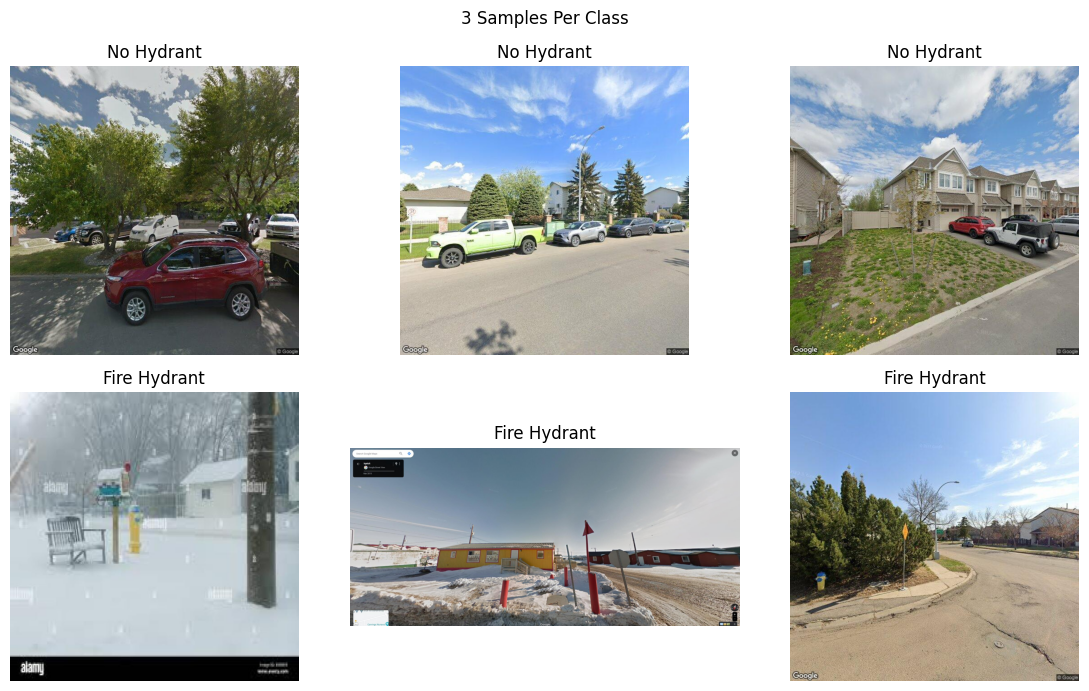

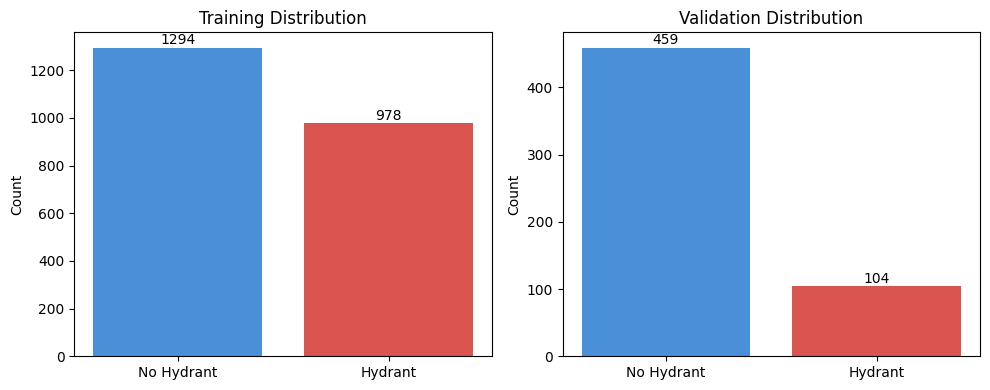

In [3]:
## Enter your code here..
# load the CSV label files
train_label = pd.read_csv('/content/train/_classes.csv')
valid_label = pd.read_csv('/content/valid/_classes.csv')

# grab column names for filename and label
fname_col = train_label.columns[0]
label_col = train_label.columns[1]

# print dataset info
print(f"Training samples: {len(train_label)}")
print(f"Validation samples: {len(valid_label)}")
print(train_label[label_col].value_counts())
print(valid_label[label_col].value_counts())

# grab 3 random samples from each class
class0 = train_label[train_label[label_col] == 0].sample(3, random_state=42)
class1 = train_label[train_label[label_col] == 1].sample(3, random_state=42)

# display sample images from each class
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for i, (_, row) in enumerate(class0.iterrows()):
    img = mpimg.imread(os.path.join(train_data_path, row[fname_col]))
    axes[0][i].imshow(img)
    axes[0][i].set_title("No Hydrant")
    axes[0][i].axis('off')

for i, (_, row) in enumerate(class1.iterrows()):
    img = mpimg.imread(os.path.join(train_data_path, row[fname_col]))
    axes[1][i].imshow(img)
    axes[1][i].set_title("Fire Hydrant")
    axes[1][i].axis('off')

plt.suptitle("3 Samples Per Class")
plt.tight_layout()
plt.show()

# plot class distribution for training and validation sets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

train_counts = train_label[label_col].value_counts().sort_index()
ax1.bar(['No Hydrant', 'Hydrant'], train_counts.values, color=['#4a90d9', '#d9534f'])
ax1.set_title('Training Distribution')
ax1.set_ylabel('Count')
for i, v in enumerate(train_counts.values):
    ax1.text(i, v + 15, str(v), ha='center')

valid_counts = valid_label[label_col].value_counts().sort_index()
ax2.bar(['No Hydrant', 'Hydrant'], valid_counts.values, color=['#4a90d9', '#d9534f'])
ax2.set_title('Validation Distribution')
ax2.set_ylabel('Count')
for i, v in enumerate(valid_counts.values):
    ax2.text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

---

### 3) Preprocessing
- Resize images to 128x128.
- Apply any other necessary transformations that you feel can help.

❓ Would one-hot encoding be necessary for binary classification? Why or why not?  
✅ No, we don't need one-hot encoding for this task. Since there are only two classes (hydrant or no hydrant), we can just use 0 and 1 as labels. The model outputs a single number between 0 and 1 using sigmoid, which already tells us which class it's predicting. One-hot encoding is more useful when you have multiple classes to keep track of.

In [4]:
## Enter your code here..
# training transforms: resize, augment with horizontal flip, normalize
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# validation transforms: resize and normalize only, no augmentation
valid_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# custom dataset class to load images and labels from csv
class HydrantDataset(Dataset):
    def __init__(self, csv_df, img_dir, transform=None):
        self.data = csv_df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img = Image.open(os.path.join(self.img_dir, row.iloc[0])).convert('RGB')
        label = row.iloc[1]
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)

# create datasets and dataloaders
train_dataset = HydrantDataset(train_label, train_data_path, train_transform)
valid_dataset = HydrantDataset(valid_label, valid_data_path, valid_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

# verify batch shape and pixel range
imgs, labels = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}")
print(f"Pixel range: {imgs.min():.2f} to {imgs.max():.2f}")

Batch shape: torch.Size([32, 3, 128, 128])
Pixel range: -0.99 to 1.00


---

### 4) Creating the Baseline Model
Create a CNN with:
- Two convolutional layers to extract features from the images.
- Max pooling layers after each convolution to reduce spatial dimensions.
- Fully connected layers to perform classification.
- A sigmoid activation function at the output layer to output a probability between 0 and 1.

Required architecture:
- Input: RGB images resized to 128x128 pixels.
- Conv2d (3 input channels, 32 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the first Conv2d.
- Conv2d (32 input channels, 64 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the second Conv2d.
- Flatten
- Linear layer with 128 units
- Output Linear layer with 1 unit and sigmoid activation



This model will be trained to classify whether an image contains a fire hydrant or not.


❓ List three ways to improve the baseline model (e.g., adding dropout to... , using batch normalization to..., or increasing the number of layers to...,
be sure to come up with your own ideas!). Provide a brief explanation for each.

✅
1. Adding dropout layers: Adding dropout layers randomly turns off some neurons during training so the model doesn't just memorize the training data and actually learns useful patterns.
2. Adding batch normalization: Adding batch normalizaiton normalizes the values between layers which helps the model train faster and more consistently.
3. Adding more convolutional layers: Add more convolutional layers gives the model more ability to pick up on complex features like shapes and edges, which could help it tell apart hydrants from other objects.

In [5]:
## Enter your code here..
# baseline CNN model for binary classification
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        # two conv layers with max pooling
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # after two poolings: 128 -> 64 -> 32, so 64 * 32 * 32
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # conv1 + pool
        x = self.pool(torch.relu(self.conv2(x)))  # conv2 + pool
        x = x.view(x.size(0), -1)  # flatten
        x = torch.relu(self.fc1(x))  # fully connected layer
        x = self.sigmoid(self.fc2(x))  # output probability
        return x

model = BaselineCNN()
print(model)

BaselineCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=65536, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


---

### 5) Training and Evaluation
Train your CNN using Binary Cross Entropy Loss and an Adam optimizer. Use a learning rate of 0.001. Iterate over your dataset for 10 epochs and track the loss. Train using the train data in /train.

Evaluate your model on the test data in /valid using Precision, Recall, and F1-Score to assess performance.


❓ Which evaluation metric you think is the most suitable in our case, and why?

✅ Recall is the most important metric here because missing a fire hydrant (false negative) is worse than incorrectly flagging something as one (false positive). If a hydrant is blocked and the model doesn't detect it, that's a potential safety issue. F1-score is also useful since it balances both precision and recall, which matters when the dataset is imbalanced.


Display the confusion matrix.

❓ Explain the confusion matrix to a non-technical audience and relate it to your chosen metric.  
✅ A confusion matrix is a table that shows what the model got right and what it got wrong. It breaks predictions into four boxes: images it correctly said had a hydrant, images it correctly said didn't, images it said had a hydrant but didn't, and images it missed that actually had one. Recall looks at that last case: out of all the real hydrants, how many did the model actually catch? A high recall means the model isn't missing many hydrants.

Epoch 1/10 - Loss: 0.5970
Epoch 2/10 - Loss: 0.4920
Epoch 3/10 - Loss: 0.4469
Epoch 4/10 - Loss: 0.3896
Epoch 5/10 - Loss: 0.3566
Epoch 6/10 - Loss: 0.2987
Epoch 7/10 - Loss: 0.2675
Epoch 8/10 - Loss: 0.1927
Epoch 9/10 - Loss: 0.1418
Epoch 10/10 - Loss: 0.1286


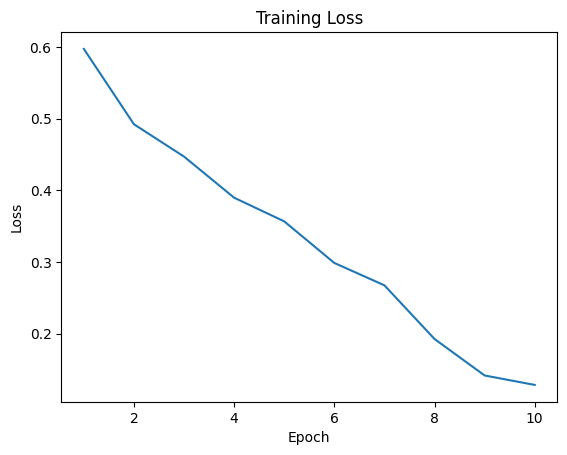


Classification Report:
              precision    recall  f1-score   support

  No Hydrant       0.92      0.77      0.84       459
     Hydrant       0.41      0.70      0.52       104

    accuracy                           0.76       563
   macro avg       0.67      0.74      0.68       563
weighted avg       0.83      0.76      0.78       563

Precision: 0.4124
Recall: 0.7019
F1-Score: 0.5196


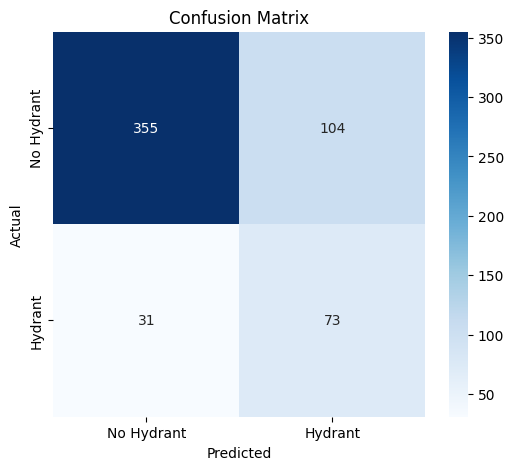

In [6]:
## Enter your code here..
# set up device, model, loss function, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BaselineCNN().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# training loop for 10 epochs
num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # track average loss per epoch
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

# plot training loss over epochs
plt.plot(range(1, num_epochs+1), train_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

# evaluate on validation set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images).squeeze()
        preds = (outputs >= 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# print classification metrics
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['No Hydrant', 'Hydrant']))
print(f"Precision: {precision_score(all_labels, all_preds):.4f}")
print(f"Recall: {recall_score(all_labels, all_preds):.4f}")
print(f"F1-Score: {f1_score(all_labels, all_preds):.4f}")

# plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Hydrant', 'Hydrant'],
            yticklabels=['No Hydrant', 'Hydrant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

---


### 6) Model Improvements
Apply and evaluate three improvements ideas that you mentioned in the Baseline CNN question (Step 4).
Implement each idea separately, train a model with that improvement, and report the performance of each model using the metrics from Step 5. As above, train using the data in /train and test using the data in /valid.


❓ Which model would you deploy? Why?  
✅ I would deploy the BatchNorm model since it had the highest F1-score 0.5574. It improved over the baseline 0.5051 by normalizing activations between layers, which stabilizes training and helps the model converge to better weights. This is especially helpful with a small, imbalanced dataset like ours. While none of the models are perfect, the BatchNorm model gives the best balance between catching hydrants and not flagging too many false positives.

IMPROVEMENT 1: Dropout
[Dropout Model] Epoch 1/10 - Loss: 0.6386
[Dropout Model] Epoch 2/10 - Loss: 0.5390
[Dropout Model] Epoch 3/10 - Loss: 0.5072
[Dropout Model] Epoch 4/10 - Loss: 0.4899
[Dropout Model] Epoch 5/10 - Loss: 0.4512
[Dropout Model] Epoch 6/10 - Loss: 0.4349
[Dropout Model] Epoch 7/10 - Loss: 0.4079
[Dropout Model] Epoch 8/10 - Loss: 0.3946
[Dropout Model] Epoch 9/10 - Loss: 0.3748
[Dropout Model] Epoch 10/10 - Loss: 0.3549


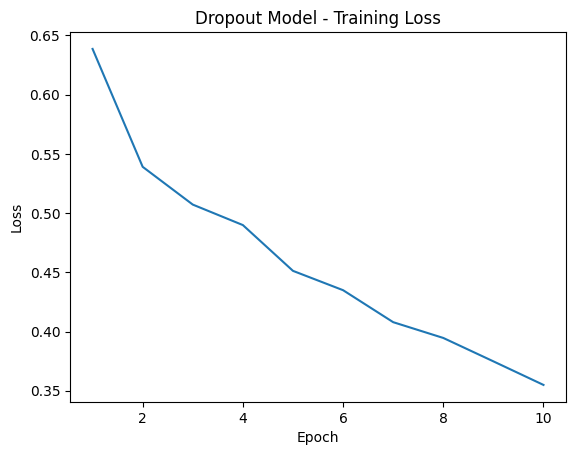


Dropout Model Results:
              precision    recall  f1-score   support

  No Hydrant       0.90      0.84      0.87       459
     Hydrant       0.46      0.61      0.52       104

    accuracy                           0.79       563
   macro avg       0.68      0.72      0.69       563
weighted avg       0.82      0.79      0.80       563

Precision: 0.4565
Recall: 0.6058
F1-Score: 0.5207


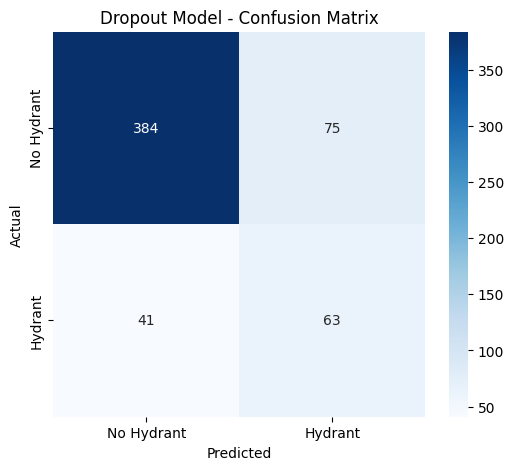

IMPROVEMENT 2: Batch Normalization
[BatchNorm Model] Epoch 1/10 - Loss: 0.5844
[BatchNorm Model] Epoch 2/10 - Loss: 0.4919
[BatchNorm Model] Epoch 3/10 - Loss: 0.4520
[BatchNorm Model] Epoch 4/10 - Loss: 0.4023
[BatchNorm Model] Epoch 5/10 - Loss: 0.4067
[BatchNorm Model] Epoch 6/10 - Loss: 0.3579
[BatchNorm Model] Epoch 7/10 - Loss: 0.3390
[BatchNorm Model] Epoch 8/10 - Loss: 0.3092
[BatchNorm Model] Epoch 9/10 - Loss: 0.2635
[BatchNorm Model] Epoch 10/10 - Loss: 0.2514


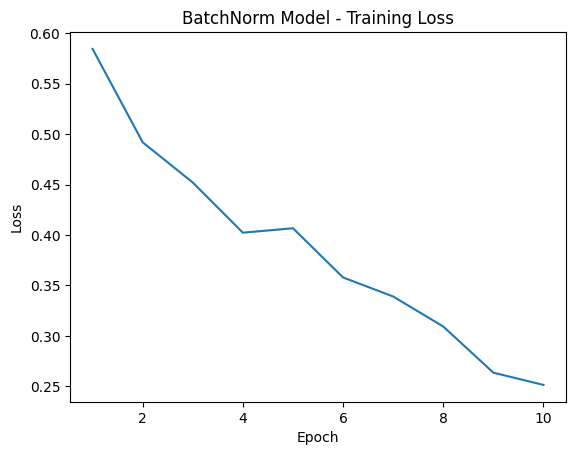


BatchNorm Model Results:
              precision    recall  f1-score   support

  No Hydrant       0.91      0.86      0.88       459
     Hydrant       0.49      0.62      0.55       104

    accuracy                           0.81       563
   macro avg       0.70      0.74      0.71       563
weighted avg       0.83      0.81      0.82       563

Precision: 0.4923
Recall: 0.6154
F1-Score: 0.5470


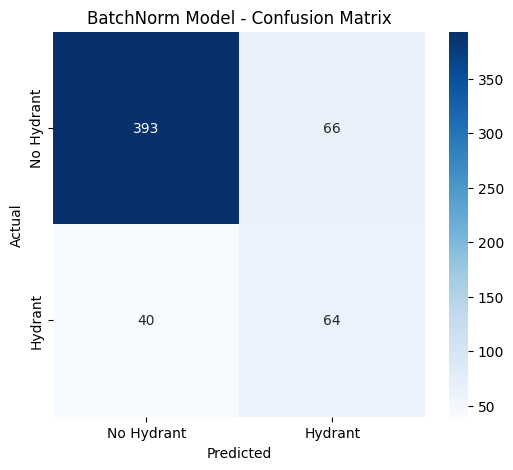

IMPROVEMENT 3: Deeper Network
[Deeper Model] Epoch 1/10 - Loss: 0.5762
[Deeper Model] Epoch 2/10 - Loss: 0.5118
[Deeper Model] Epoch 3/10 - Loss: 0.4763
[Deeper Model] Epoch 4/10 - Loss: 0.4533
[Deeper Model] Epoch 5/10 - Loss: 0.4274
[Deeper Model] Epoch 6/10 - Loss: 0.4071
[Deeper Model] Epoch 7/10 - Loss: 0.3867
[Deeper Model] Epoch 8/10 - Loss: 0.3483
[Deeper Model] Epoch 9/10 - Loss: 0.3230
[Deeper Model] Epoch 10/10 - Loss: 0.2786


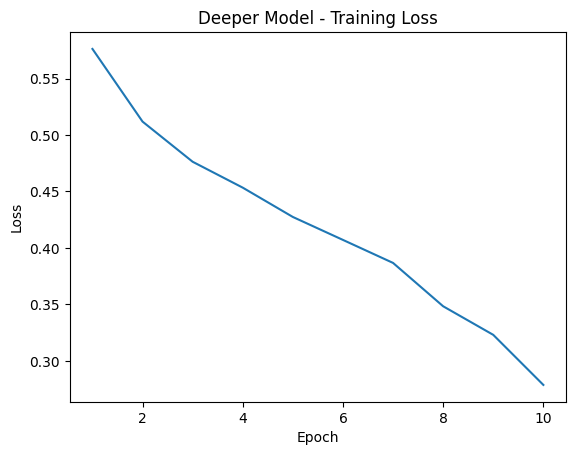


Deeper Model Results:
              precision    recall  f1-score   support

  No Hydrant       0.92      0.79      0.85       459
     Hydrant       0.43      0.69      0.53       104

    accuracy                           0.77       563
   macro avg       0.68      0.74      0.69       563
weighted avg       0.83      0.77      0.79       563

Precision: 0.4311
Recall: 0.6923
F1-Score: 0.5314


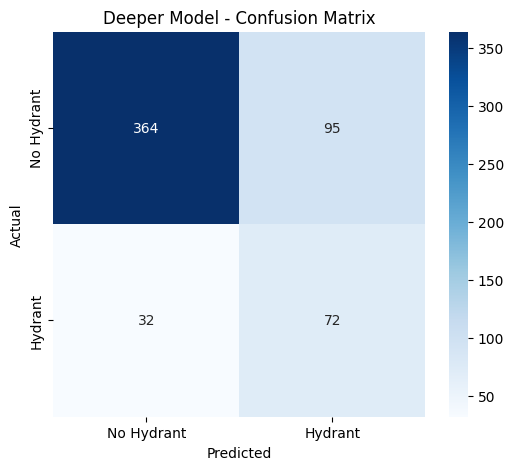


SUMMARY
Dropout Model F1:    0.5207
BatchNorm Model F1:  0.5470
Deeper Model F1:     0.5314


In [7]:
## Enter your code here..
# helper function to train and evaluate a model
def train_and_evaluate(model, name, num_epochs=10, lr=0.001):
    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses = []

    # training loop
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # track average loss per epoch
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"[{name}] Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

    # plot training loss over epochs
    plt.plot(range(1, num_epochs+1), train_losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{name} - Training Loss')
    plt.show()

    # evaluate on validation set
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze()
            preds = (outputs >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # print classification metrics
    print(f"\n{name} Results:")
    print(classification_report(all_labels, all_preds, target_names=['No Hydrant', 'Hydrant']))
    print(f"Precision: {precision_score(all_labels, all_preds):.4f}")
    print(f"Recall: {recall_score(all_labels, all_preds):.4f}")
    print(f"F1-Score: {f1_score(all_labels, all_preds):.4f}")

    # plot confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Hydrant', 'Hydrant'],
                yticklabels=['No Hydrant', 'Hydrant'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()

    # return the trained model and its f1 score
    f1 = f1_score(all_labels, all_preds)
    return model, f1


# Improvement 1: Adding Dropout to reduce overfitting
# Dropout randomly disables neurons during training to prevent memorization
class CNN_Dropout(nn.Module):
    def __init__(self):
        super(CNN_Dropout, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(0.5)  # 50% dropout rate
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))  # apply dropout after fc1
        x = self.sigmoid(self.fc2(x))
        return x

print("=" * 50)
print("IMPROVEMENT 1: Dropout")
print("=" * 50)
dropout_model, f1_dropout = train_and_evaluate(CNN_Dropout(), "Dropout Model")


# Improvement 2: Batch Normalization to stabilize training
# BatchNorm normalizes activations between layers for faster, more stable learning
class CNN_BatchNorm(nn.Module):
    def __init__(self):
        super(CNN_BatchNorm, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)  # normalize after first conv
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)  # normalize after second conv
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

print("=" * 50)
print("IMPROVEMENT 2: Batch Normalization")
print("=" * 50)
batchnorm_model, f1_batchnorm = train_and_evaluate(CNN_BatchNorm(), "BatchNorm Model", lr=0.0001)


# Improvement 3: Deeper network with an extra conv layer
# Adding a third conv layer lets the model learn more complex features
class CNN_Deeper(nn.Module):
    def __init__(self):
        super(CNN_Deeper, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)  # extra conv layer
        # after 3 poolings: 128 -> 64 -> 32 -> 16
        self.fc1 = nn.Linear(128 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

print("=" * 50)
print("IMPROVEMENT 3: Deeper Network")
print("=" * 50)
deeper_model, f1_deeper = train_and_evaluate(CNN_Deeper(), "Deeper Model")

# summary of all three improvements
print("\n" + "=" * 50)
print("SUMMARY")
print("=" * 50)
print(f"Dropout Model F1:    {f1_dropout:.4f}")
print(f"BatchNorm Model F1:  {f1_batchnorm:.4f}")
print(f"Deeper Model F1:     {f1_deeper:.4f}")

---

### 7) Personal Inference Test
Test your trained model on at least FIVE new images (either collected using a camera or collected from the internet). Predict whether each image contains a fire hydrant and print the result.

Of your five images:
- Include at least one image of a fire hydrant that your model does not detect correctly.
- Include at least one image of a fire hydrant that your model does detect correctly.

❓ Challenge: Can you find an image that does not actually contain a fire hydrant, but your model believes that a hydrant is present?

✅ Yes, test4: the red barrel was predicted as "Hydrant" with 1.00 confidence even though it does not contain a fire hydrant. The model believed it was a hydrant because of the red color and cylindrical shape, which are features it associates with hydrants.

❓ Explain why you believe your model performed the way it did on each of your five images. What patterns or mistakes do you observe?

✅
- Test 1 (Hydrant on grass, Conf: 0.04) – Incorrect (False Negative). Despite the hydrant being clearly visible and centered, the model predicted "No Hydrant" with very low confidence. This may be because the image has a very bright, uniform green background which is different from the typical street scenes in the training data. The model may not have seen enough hydrants on plain grass backgrounds.

- Test 2 (Hydrant hidden behind bushes, Conf: 0.47) – Incorrect (False Negative). The model predicted "No Hydrant" but was close to the 0.5 threshold. The hydrant is mostly hidden by bushes, so it makes sense the model struggled. It possibly could not pick up enough visible features of the hydrant through the bushes.

- Test 3 (Hydrant against stone wall, Conf: 0.99) – Correct. The red hydrant is clearly visible on the sidewalk. The high confidence makes sense since the hydrant is unobstructed and set against a typical urban background similar to training data.

- Test 4 (Red barrel, Conf: 1.00) – Incorrect (False Positive). The model predicted hydrant with full confidence on a red barrel. This shows the model relies heavily on color (red) and shape (cylindrical) rather than understanding structural details of a hydrant like nozzles or caps.

- Test 5 (Red/green hydrant, Conf: 0.99) – Correct. The hydrant is clearly visible outdoors on grass in a typical urban setting, which is similar to scenes the model was trained on.


In [8]:
!unzip /content/A2Images.zip -d /content/

Archive:  /content/A2Images.zip
   creating: /content/A2Images/
  inflating: /content/A2Images/test1.jpeg  
  inflating: /content/A2Images/test2.jpeg  
  inflating: /content/A2Images/test3.jpeg  
  inflating: /content/A2Images/test4.jpeg  
  inflating: /content/A2Images/test5.jpeg  


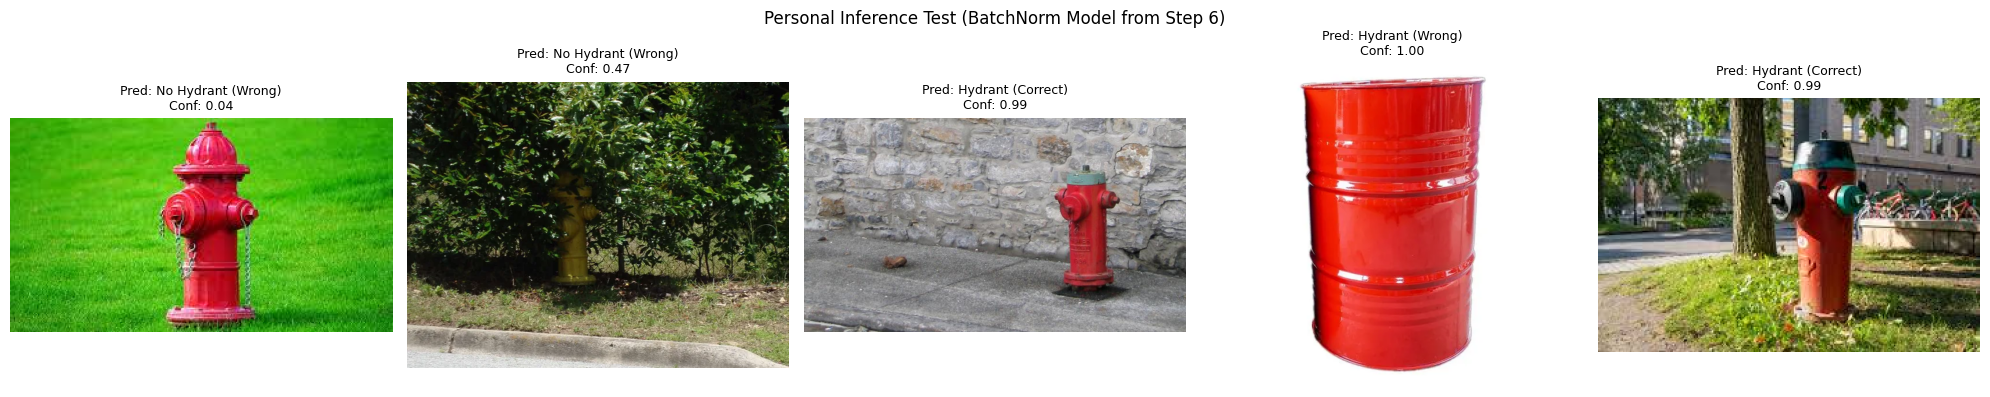

In [12]:
## Enter your code here..
from PIL import Image

# test images with descriptions of what they contain
test_images = [
    ('A2Images/test1.jpeg', 'Hydrant - clear, on grass'),
    ('A2Images/test2.jpeg', 'Hydrant - hidden behind bushes'),
    ('A2Images/test3.jpeg', 'Hydrant - red, against stone wall'),
    ('A2Images/test4.jpeg', 'No hydrant - red barrel'),
    ('A2Images/test5.jpeg', 'Hydrant - red/green, on grass'),
]

# use the trained BatchNorm model from Step 6
batchnorm_model.eval()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (img_path, desc) in enumerate(test_images):
    # load and preprocess the image
    img = Image.open(img_path).convert('RGB')
    img_tensor = valid_transform(img).unsqueeze(0).to(device)

    # predict
    with torch.no_grad():
        output = batchnorm_model(img_tensor).item()

    pred = "Hydrant" if output >= 0.5 else "No Hydrant"
    correct_label = "Hydrant" if "No hydrant" not in desc else "No Hydrant"
    status = "Correct" if pred == correct_label else "Wrong"

    # display image with prediction
    axes[i].imshow(img)
    axes[i].set_title(f"Pred: {pred} ({status})\nConf: {output:.2f}", fontsize=9)
    axes[i].axis('off')

plt.suptitle("Personal Inference Test (BatchNorm Model from Step 6)")
plt.tight_layout()
plt.show()

---

### 8) (Optional) Transfer Learning with Pretrained CNN

#### Description:
In this optional step, fine-tune a pretrained CNN (e.g., ResNet50) on your dataset and compare its performance to your custom CNN.

- Use `torchvision.models.resnet50(pretrained=True)` as a starting model.

Reference: https://pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html
- Modify the final layer to fit your binary classification task (fire hydrant vs. no fire hydrant).
- Resize input images to **256x256** pixels.
- Fine-tune the model and evaluate its performance.
- Compare the results to your custom CNN in terms of accuracy, training time, and other relevant metrics.

#### Libraries to use:
```python
import torchvision.models as models
```

#### Student Code:
```python
# Your code here
```


------

### 9) Final Thoughts
❓ How would you improve the model in the future?

✅ There are several ways I would improve the model in the future. First, I would use class weights in the loss function to address the dataset imbalance, giving more importance to the minority hydrant class so the model doesn't bias toward predicting "No Hydrant." Second, I would use more data augmentation techniques like random rotation, color jitter, and random cropping to expose the model to more varied training examples and reduce overfitting. Third, I would use transfer learning with a pretrained model like ResNet50, which has already been trained on millions of images and would likely perform much better than a simple custom CNN on a small dataset like ours. Finally, I would train for more epochs with a learning rate scheduler to let the model converge more gradually, and experiment with a lower decision threshold (e.g., 0.3 instead of 0.5) to improve recall for the hydrant class, since missing a hydrant is more costly than a false alarm.


-----

## Final Question:
### ❓ Did you use an AI tool in completing your assignment? If yes, which AI tool(s) did you use? How did you prompt it? How you validate the response?

✅ I used AI tools like ChatGPT to brainstorm ideas and do initial research on concepts like batch normalization and dropout. However, I wrote my code and answers based on the course lectures, PyTorch documentation, and tutorials covered in class. I validated everything by running the code in Colab and making sure the results were consistent with what we learned in the course.


---

## Submission
Submit your `.ipynb` notebook on Brightspace using the following name format:  
`SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb`

